# Feature Engineering

This notebook builds the modeling feature set from the imputed base dataset.

Steps:
1. **Feature drops** — remove columns identified as redundant in the correlation analysis
2. **Rolling momentum** — 3-month and 12-month rolling means of key growth signals
3. **Volatility** — 3-month rolling standard deviation of price momentum
4. **Acceleration** — short-term momentum minus long-term momentum (is pressure building?)
5. **Affordability ratios** — price and rent relative to local income
6. **ZIP-relative departure** — how far is each ZIP from its own recent baseline?
7. **Lagged features** — key signals at t−3 and t−6 months

**All rolling and lag operations are computed within each ZIP.**  
No future information is used — every feature at month `t` uses only data available at or before `t`.

Input:  `data/processed/modeling_ready.csv`  
Output: `data/processed/features_engineered.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.dpi'] = 120

INPUT_PATH  = '../data/processed/modeling_ready.csv'
OUTPUT_PATH = '../data/processed/features_engineered.csv'

---
## 1. Load Data

In [2]:
df = pd.read_csv(INPUT_PATH)
df['month'] = pd.to_datetime(df['month'])
df['zip']   = df['zip'].astype(str).str.zfill(5)
df = df.sort_values(['zip', 'month']).reset_index(drop=True)

# drop 'year' — redundant with month, must not be used as a model feature
df = df.drop(columns=['year'])

print(f'Shape: {df.shape}')
print(f'ZIPs: {df["zip"].nunique()}')
print(f'Date range: {df["month"].min().date()} → {df["month"].max().date()}')

Shape: (55944, 39)
ZIPs: 666
Date range: 2018-01-31 → 2024-12-31


---
## 2. Feature Drops

Based on the correlation analysis in `data_prep_and_eda.ipynb`.  
Only columns with **GENUINE** verdict are dropped here — columns marked TREND or REVIEW are kept for now and left to model feature importance to resolve.

| Dropped | Reason |
|---|---|
| `q1_payroll` | Near-duplicate of `annual_payroll`; `avg_pay_per_employee` is more informative |
| `annual_payroll` | Redundant once we keep `total_employment` + `avg_pay_per_employee` |
| `mortgage_rate_15yr` | Near-duplicate of `mortgage_rate_30yr` (r=0.995 in both levels and differences) |
| `mortgage_rate_5_1_arm` | Near-duplicate of `mortgage_rate_30yr`; `mortgage_arm_spread` captures the differential |
| `pending_sales` | Highly correlated with `homes_sold` and `new_listings` in differences — not just levels |
| `wages_and_salaries` | Subset of `adjusted_gross_income`; AGI is broader and already in the set |
| `median_list_price_per_sqft` | Near-duplicate of `median_price_per_sqft` in differences |
| `ordinary_dividends` | Wealth proxy already captured by `adjusted_gross_income` |

In [3]:
DROP_COLS = [
    'q1_payroll',
    'annual_payroll',
    'mortgage_rate_15yr',
    'mortgage_rate_5_1_arm',
    'pending_sales',
    'wages_and_salaries',
    'median_list_price_per_sqft',
    'ordinary_dividends',
]

df = df.drop(columns=DROP_COLS)
print(f'Shape after drops: {df.shape}')
print(f'Remaining columns ({len(df.columns)}):')
print([c for c in df.columns if c not in ('zip', 'month')])

Shape after drops: (55944, 31)
Remaining columns (31):
['home_value_index', 'median_sale_price', 'median_list_price', 'median_price_per_sqft', 'homes_sold', 'new_listings', 'inventory', 'median_days_on_market', 'avg_sale_to_list_ratio', 'pct_sold_above_list', 'pct_off_market_in_2wks', 'mortgage_rate_30yr', 'mortgage_arm_spread', 'median_household_income', 'median_owner_home_value', 'median_gross_rent', 'owner_occupancy_rate', 'business_establishments', 'total_employment', 'avg_pay_per_employee', 'tax_returns_filed', 'adjusted_gross_income', 'taxable_interest_income', 'home_value_mom_pct', 'home_value_yoy_pct', 'sale_price_mom_pct', 'sale_price_yoy_pct', 'inventory_mom_pct', 'inventory_yoy_pct']


---
## 3. Feature Engineering

### Implementation notes
- All rolling and lag operations use `groupby('zip')` — each ZIP's history is treated independently
- Rolling windows use `min_periods` equal to the window size — partial windows are left as NaN rather than computed on insufficient data
- This means the first N−1 months of each ZIP will have NaN for N-period features, which is expected and audited in Section 4
- All features at month `t` use only data at or before `t` — no lookahead

In [4]:
# Helper: apply a rolling function within each ZIP
def zip_rolling(series, window, func='mean'):
    return (
        series
        .groupby(df['zip'])
        .transform(lambda s: getattr(s.rolling(window, min_periods=window), func)())
    )

# Helper: lag within each ZIP
def zip_lag(series, periods):
    return (
        series
        .groupby(df['zip'])
        .transform(lambda s: s.shift(periods))
    )

### 3a. Rolling Momentum

Rolling means of the existing MoM signals smooth out month-to-month noise and reveal sustained directional pressure.  
- **3-month** captures short-term momentum (is the ZIP accelerating right now?)  
- **12-month** captures sustained trend (has this ZIP been consistently moving in this direction?)  

We also apply 3-month smoothing to the competitiveness metrics, which are noisy month-to-month.

In [5]:
# --- 3-month rolling means ---
df['home_value_mom_3m_avg']    = zip_rolling(df['home_value_mom_pct'],   3)
df['sale_price_mom_3m_avg']    = zip_rolling(df['sale_price_mom_pct'],   3)
df['inventory_mom_3m_avg']     = zip_rolling(df['inventory_mom_pct'],    3)
df['pct_above_list_3m_avg']    = zip_rolling(df['pct_sold_above_list'],  3)
df['sale_to_list_3m_avg']      = zip_rolling(df['avg_sale_to_list_ratio'], 3)
df['off_market_2wk_3m_avg']    = zip_rolling(df['pct_off_market_in_2wks'], 3)

# --- 12-month rolling means ---
df['home_value_mom_12m_avg']   = zip_rolling(df['home_value_mom_pct'],   12)
df['sale_price_mom_12m_avg']   = zip_rolling(df['sale_price_mom_pct'],   12)
df['inventory_mom_12m_avg']    = zip_rolling(df['inventory_mom_pct'],    12)

print('Rolling momentum features added.')

Rolling momentum features added.


### 3b. Rolling Volatility

Standard deviation of price momentum over 3 months.  
High volatility can signal a market in flux — potentially a transition in progress or about to begin.

In [6]:
df['home_value_mom_3m_std']  = zip_rolling(df['home_value_mom_pct'],  3, func='std')
df['sale_price_mom_3m_std']  = zip_rolling(df['sale_price_mom_pct'],  3, func='std')

print('Volatility features added.')

Volatility features added.


### 3c. Acceleration

Acceleration = short-term rolling average minus long-term rolling average of momentum.  
- Positive → momentum is building (recent growth exceeds the long-run average)
- Negative → momentum is fading

This is one of the strongest early-warning signals — a ZIP that has been growing slowly for years but suddenly accelerates is more interesting than one that has always been hot.

In [7]:
df['home_value_accel']  = df['home_value_mom_3m_avg']  - df['home_value_mom_12m_avg']
df['sale_price_accel']  = df['sale_price_mom_3m_avg']  - df['sale_price_mom_12m_avg']
df['inventory_accel']   = df['inventory_mom_3m_avg']   - df['inventory_mom_12m_avg']

print('Acceleration features added.')

Acceleration features added.


### 3d. Affordability Ratios

Affordability pressure is a key contextual signal.  
A ZIP where home values are rising much faster than incomes is experiencing affordability compression — a known precursor to market pressure and displacement.

- **price_to_income_ratio**: how many years of household income does the median home cost?
- **rent_to_income_ratio**: what share of annual income goes to rent? (annualised gross rent / income)
- **price_to_rent_ratio**: classic investor metric — is it cheaper to buy or rent relative to asset value?

In [8]:
# Annualise gross rent (monthly → annual) for ratio consistency
annual_rent = df['median_gross_rent'] * 12

df['price_to_income_ratio'] = df['home_value_index']  / df['median_household_income']
df['rent_to_income_ratio']  = annual_rent             / df['median_household_income']
df['price_to_rent_ratio']   = df['home_value_index']  / annual_rent.replace(0, np.nan)

# Sanity check: a few expected ranges
print('price_to_income_ratio — median:', df['price_to_income_ratio'].median().round(2))
print('rent_to_income_ratio  — median:', df['rent_to_income_ratio'].median().round(2))
print('price_to_rent_ratio   — median:', df['price_to_rent_ratio'].median().round(2))
print('Affordability ratio features added.')

price_to_income_ratio — median: 3.91


rent_to_income_ratio  — median: 0.19
price_to_rent_ratio   — median: 21.07
Affordability ratio features added.


### 3e. ZIP-Relative Departure from Own Baseline

This is the core early-warning signal family.

Rather than asking "is this ZIP expensive?", we ask **"is this ZIP significantly above or below where it usually is?"**

Formula: `(current value / 12-month rolling mean) − 1`

A value of +0.15 means the current value is 15% above this ZIP's own 12-month average — a meaningful departure from its own baseline regardless of whether the ZIP is cheap or expensive in absolute terms.

Applied to:
- **Home value** — is the ZIP's value accelerating above its own trend?
- **Sale price** — is actual transaction price departing from baseline?
- **Inventory** — is supply unusually low relative to this ZIP's own history? (negative = tightening)
- **Days on market** — are homes selling faster than usual for this ZIP? (negative = heating up)

In [9]:
def zip_relative_departure(series, window=12):
    """(current / rolling mean) - 1, within each ZIP."""
    rolling_mean = (
        series
        .groupby(df['zip'])
        .transform(lambda s: s.rolling(window, min_periods=window).mean())
    )
    return (series / rolling_mean.replace(0, np.nan)) - 1

df['home_value_vs_baseline']   = zip_relative_departure(df['home_value_index'])
df['sale_price_vs_baseline']   = zip_relative_departure(df['median_sale_price'])
df['inventory_vs_baseline']    = zip_relative_departure(df['inventory'])
df['dom_vs_baseline']          = zip_relative_departure(df['median_days_on_market'])

print('ZIP-relative departure features added.')
print()
# Show distribution of departures across all ZIP-months
dep_cols = ['home_value_vs_baseline', 'sale_price_vs_baseline',
            'inventory_vs_baseline', 'dom_vs_baseline']
df[dep_cols].describe().round(3)

ZIP-relative departure features added.



,home_value_vs_baseline,sale_price_vs_baseline,inventory_vs_baseline,dom_vs_baseline
count,48618.0000,48618.0000,48618.0000,48618.0000
mean,0.0410,0.0470,0.0040,-0.0160
std,0.0330,0.1490,0.2830,0.3500
min,-0.1070,-0.9500,-0.9560,-0.9930
25%,0.0180,-0.0150,-0.1700,-0.2080
50%,0.0320,0.0400,-0.0130,-0.0590
75%,0.0620,0.1020,0.1480,0.1250
max,0.2250,2.7580,2.9090,4.6250


### 3f. Lagged Features

Lagged values give the model direct access to where the ZIP stood 3 and 6 months ago.  
Combined with the current value, this lets the model learn directional trajectories.

For example: a ZIP where `pct_sold_above_list` was 0.10 three months ago and is now 0.35 is very different from one that has been stable at 0.35 — even though both look identical in the current-month snapshot.

In [10]:
LAG_FEATURES = [
    'home_value_mom_pct',
    'sale_price_mom_pct',
    'inventory_mom_pct',
    'pct_sold_above_list',
    'avg_sale_to_list_ratio',
    'home_value_vs_baseline',
    'sale_price_vs_baseline',
    'inventory_vs_baseline',
]

for col in LAG_FEATURES:
    df[f'{col}_lag3'] = zip_lag(df[col], 3)
    df[f'{col}_lag6'] = zip_lag(df[col], 6)

print(f'Lagged features added: {len(LAG_FEATURES) * 2} columns')

Lagged features added: 16 columns


---
## 4. NaN Audit

Rolling windows and lags create NaNs at the start of each ZIP's history — this is expected and correct.  
The first `window − 1` months of each ZIP will be NaN for that feature.

| Feature type | Expected NaN months per ZIP |
|---|---|
| 3-month rolling | First 2 months |
| 12-month rolling | First 11 months |
| Acceleration (uses 12m avg) | First 11 months |
| ZIP-relative departure (12m window) | First 11 months |
| Lag 3 | First 3 months |
| Lag 6 | First 6 months |

These NaNs will be dropped when the target variable is attached and the final modeling dataset is assembled.

In [11]:
# Separate base columns from engineered columns
BASE_COLS = [
    'home_value_index',
    'median_sale_price', 'median_list_price', 'median_price_per_sqft',
    'homes_sold', 'new_listings', 'inventory', 'median_days_on_market',
    'avg_sale_to_list_ratio', 'pct_sold_above_list', 'pct_off_market_in_2wks',
    'mortgage_rate_30yr', 'mortgage_arm_spread',
    'median_household_income', 'median_owner_home_value', 'median_gross_rent', 'owner_occupancy_rate',
    'business_establishments', 'total_employment', 'avg_pay_per_employee',
    'tax_returns_filed', 'adjusted_gross_income', 'taxable_interest_income',
    'home_value_mom_pct', 'home_value_yoy_pct',
    'sale_price_mom_pct', 'sale_price_yoy_pct',
    'inventory_mom_pct', 'inventory_yoy_pct',
]

ENGINEERED_COLS = [c for c in df.columns if c not in BASE_COLS + ['zip', 'month']]

print(f'Base features:       {len(BASE_COLS)}')
print(f'Engineered features: {len(ENGINEERED_COLS)}')
print(f'Total features:      {len(BASE_COLS) + len(ENGINEERED_COLS)}')
print()
print('Engineered feature list:')
for c in ENGINEERED_COLS:
    print(f'  {c}')

Base features:       29
Engineered features: 37
Total features:      66

Engineered feature list:
  home_value_mom_3m_avg
  sale_price_mom_3m_avg
  inventory_mom_3m_avg
  pct_above_list_3m_avg
  sale_to_list_3m_avg
  off_market_2wk_3m_avg
  home_value_mom_12m_avg
  sale_price_mom_12m_avg
  inventory_mom_12m_avg
  home_value_mom_3m_std
  sale_price_mom_3m_std
  home_value_accel
  sale_price_accel
  inventory_accel
  price_to_income_ratio
  rent_to_income_ratio
  price_to_rent_ratio
  home_value_vs_baseline
  sale_price_vs_baseline
  inventory_vs_baseline
  dom_vs_baseline
  home_value_mom_pct_lag3
  home_value_mom_pct_lag6
  sale_price_mom_pct_lag3
  sale_price_mom_pct_lag6
  inventory_mom_pct_lag3
  inventory_mom_pct_lag6
  pct_sold_above_list_lag3
  pct_sold_above_list_lag6
  avg_sale_to_list_ratio_lag3
  avg_sale_to_list_ratio_lag6
  home_value_vs_baseline_lag3
  home_value_vs_baseline_lag6
  sale_price_vs_baseline_lag3
  sale_price_vs_baseline_lag6
  inventory_vs_baseline_lag3
  inv

In [12]:
# NaN counts for engineered features only
eng_miss = pd.DataFrame({
    'missing_count': df[ENGINEERED_COLS].isna().sum(),
    'missing_pct':   (df[ENGINEERED_COLS].isna().mean() * 100).round(1),
    'expected_nan_rows': '',
}).sort_values('missing_count', ascending=False)

# annotate expected vs unexpected
expected_3m  = 2 * df['zip'].nunique()   # first 2 months × 540 ZIPs
expected_12m = 11 * df['zip'].nunique()  # first 11 months × 540 ZIPs
expected_lag3 = 3 * df['zip'].nunique()
expected_lag6 = 6 * df['zip'].nunique()

print(f'Expected NaNs — 3m features:  {expected_3m:,}')
print(f'Expected NaNs — 12m features: {expected_12m:,}')
print(f'Expected NaNs — lag3:          {expected_lag3:,}')
print(f'Expected NaNs — lag6:          {expected_lag6:,}')
print()
eng_miss[['missing_count', 'missing_pct']]

Expected NaNs — 3m features:  1,332
Expected NaNs — 12m features: 7,326
Expected NaNs — lag3:          1,998
Expected NaNs — lag6:          3,996



,missing_count,missing_pct
inventory_vs_baseline_lag6,11322,20.2000
home_value_vs_baseline_lag6,11322,20.2000
sale_price_vs_baseline_lag6,11322,20.2000
home_value_vs_baseline_lag3,9324,16.7000
sale_price_vs_baseline_lag3,9324,16.7000
inventory_vs_baseline_lag3,9324,16.7000
dom_vs_baseline,7326,13.1000
inventory_mom_12m_avg,7326,13.1000
sale_price_accel,7326,13.1000
home_value_accel,7326,13.1000


In [13]:
# --- How many rows have a complete feature set (no NaNs in any engineered column)? ---
complete_mask = df[ENGINEERED_COLS].notna().all(axis=1)
complete_rows = complete_mask.sum()

print(f'Rows with complete engineered features: {complete_rows:,} / {len(df):,} ({complete_rows/len(df)*100:.1f}%)')
print()

# The limiting factor is the 12-month rolling window (needs 11 prior months per ZIP).
# Combined with the 6-month lag, we need at least 17 months of history per ZIP.
# With 60 months total (Jan 2018 – Dec 2022), the effective modeling window starts around Jun 2019.
first_complete_month = df.loc[complete_mask, 'month'].min()
print(f'First month with complete features across all ZIPs: {first_complete_month.date()}')
print(f'Remaining modeling months: {df.loc[complete_mask, "month"].nunique()}')

Rows with complete engineered features: 44,287 / 55,944 (79.2%)

First month with complete features across all ZIPs: 2019-06-30
Remaining modeling months: 67


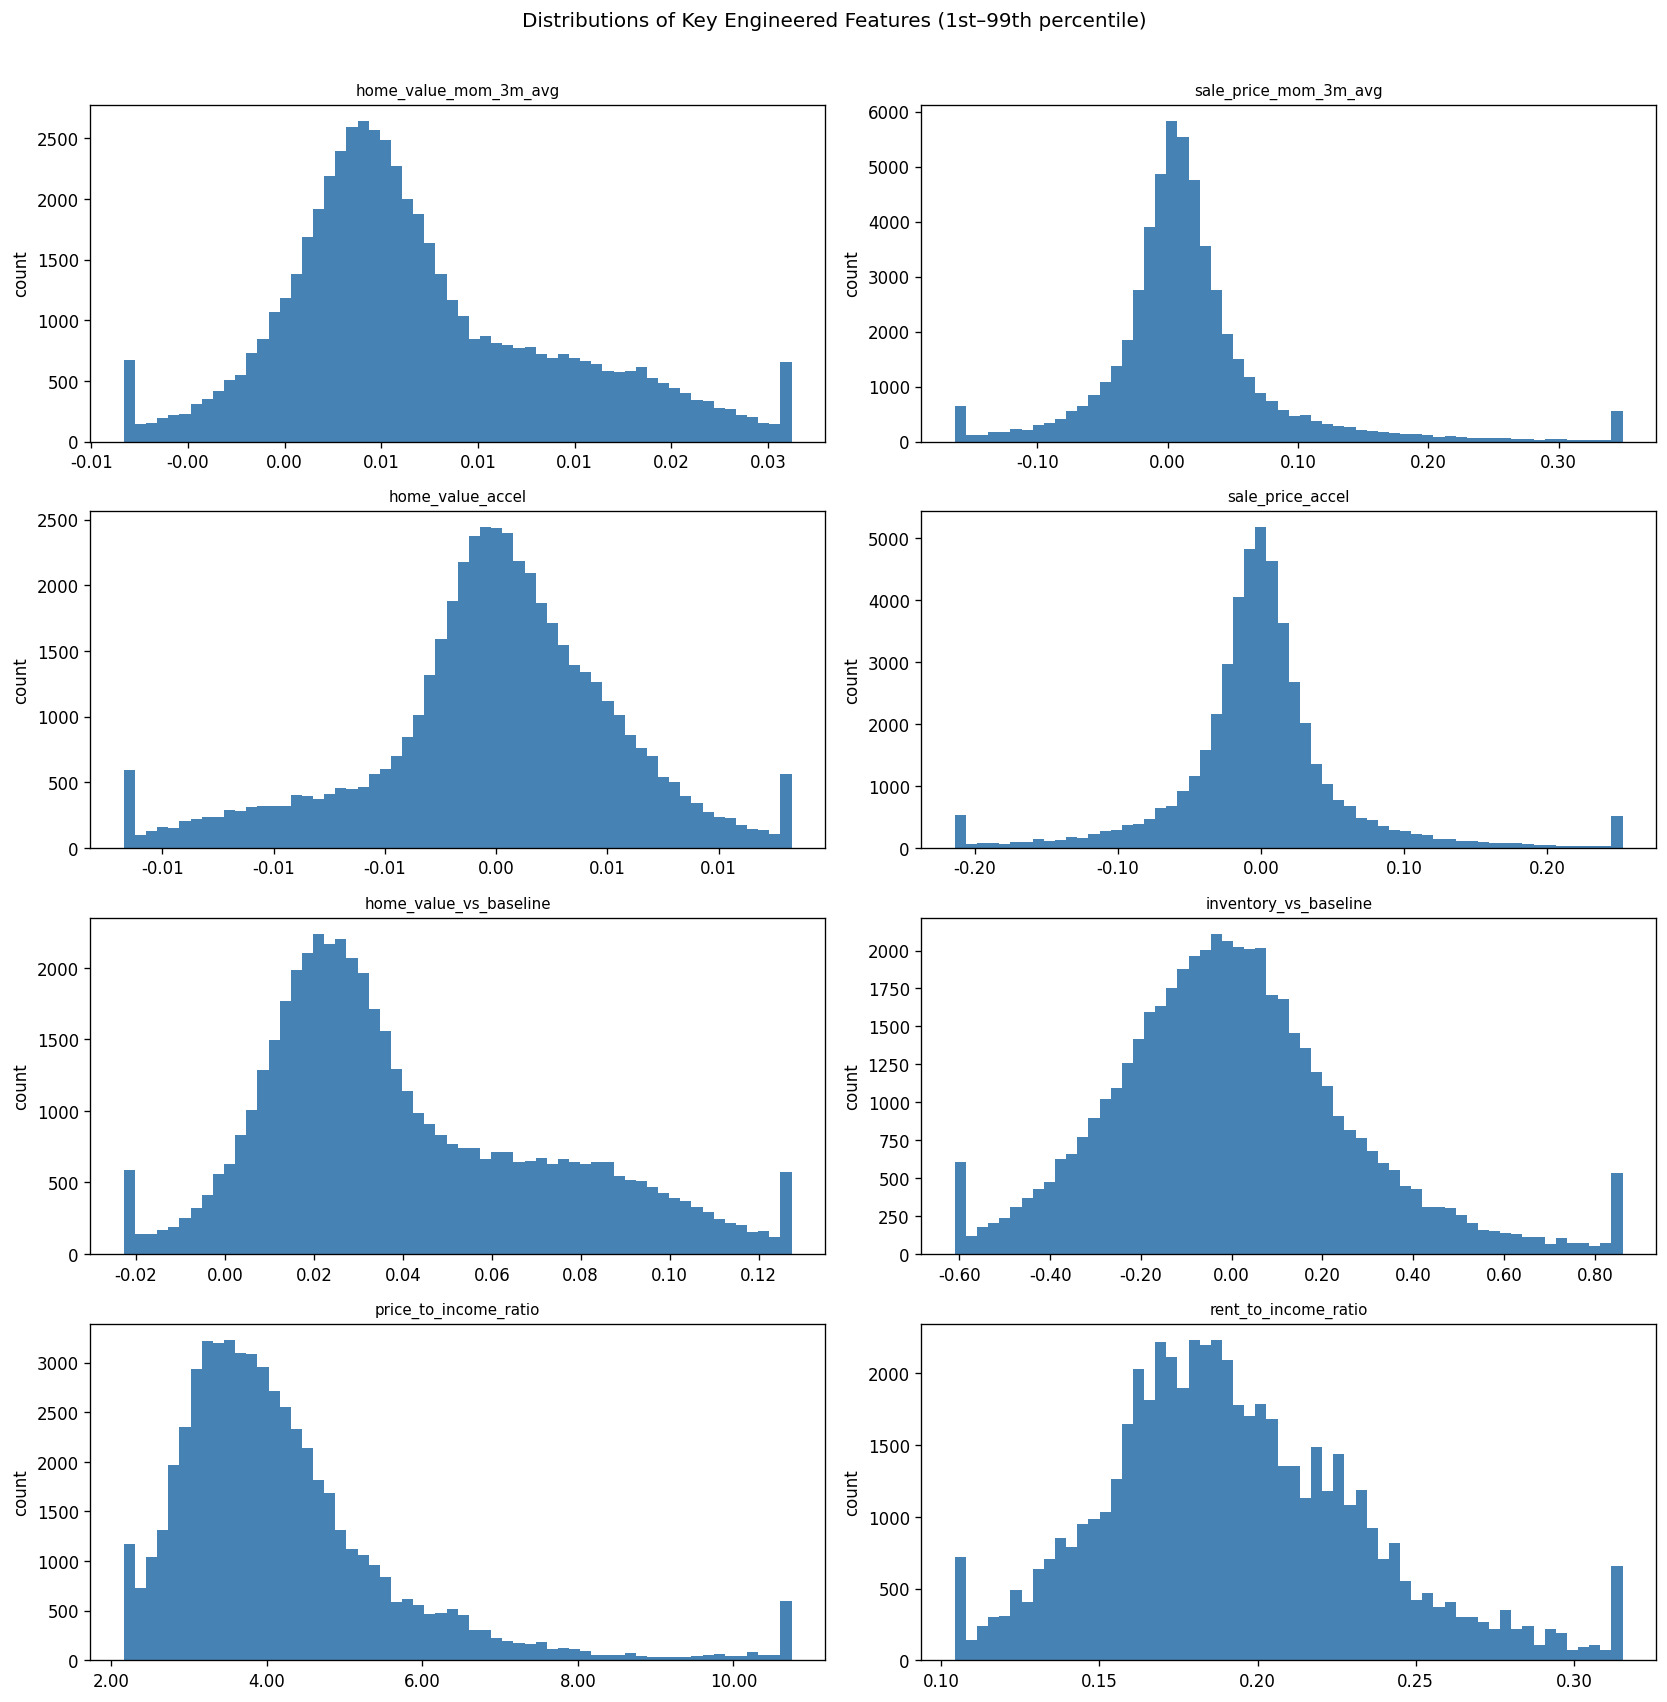

In [14]:
# --- Distribution of key engineered features ---
PLOT_COLS = [
    'home_value_mom_3m_avg', 'sale_price_mom_3m_avg',
    'home_value_accel', 'sale_price_accel',
    'home_value_vs_baseline', 'inventory_vs_baseline',
    'price_to_income_ratio', 'rent_to_income_ratio',
]

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(PLOT_COLS):
    data = df[col].dropna()
    # clip extreme outliers for readability
    low, high = data.quantile(0.01), data.quantile(0.99)
    axes[i].hist(data.clip(low, high), bins=60, color='steelblue', edgecolor='none')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('count')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.suptitle('Distributions of Key Engineered Features (1st–99th percentile)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

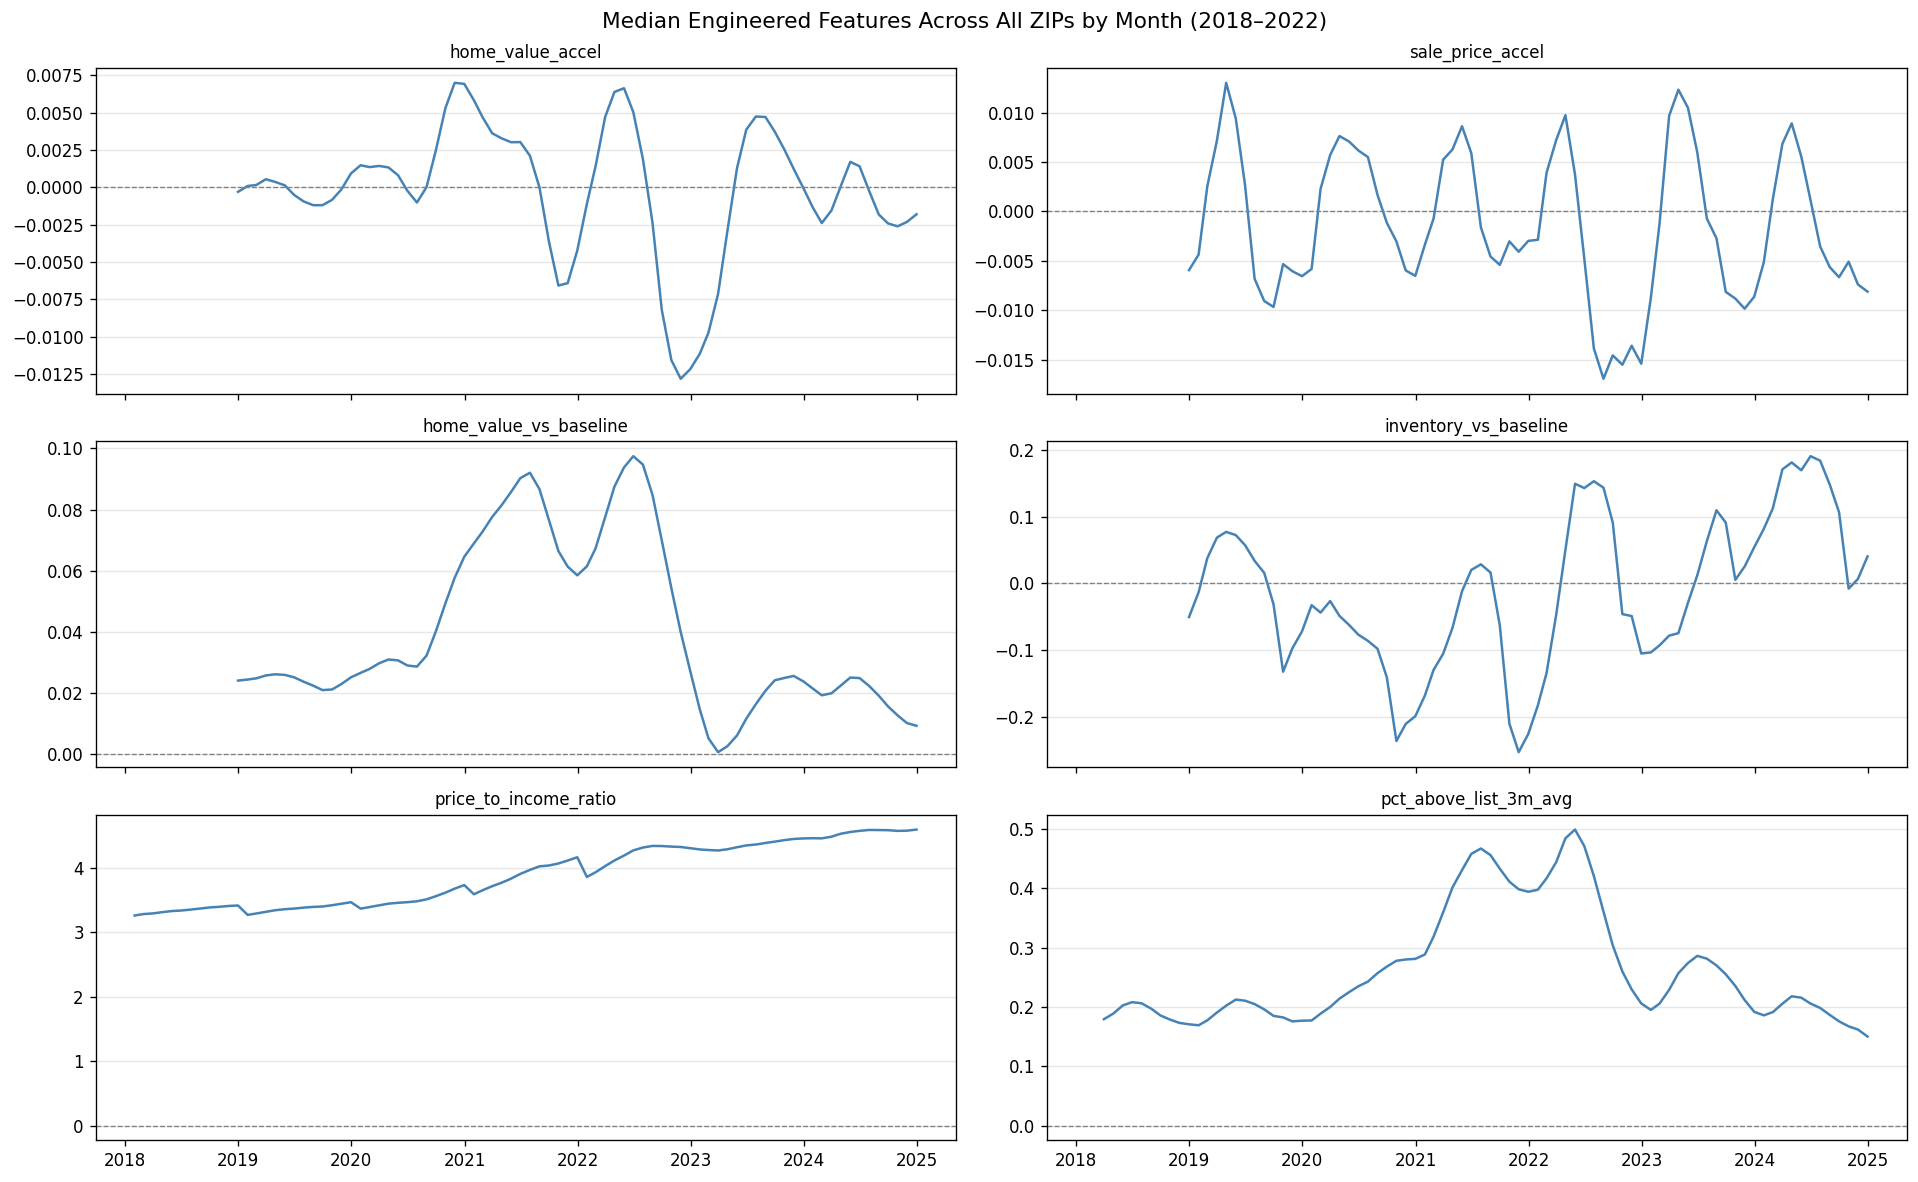

In [15]:
# --- Time trends of key engineered features across all ZIPs ---
TREND_COLS = [
    'home_value_accel', 'sale_price_accel',
    'home_value_vs_baseline', 'inventory_vs_baseline',
    'price_to_income_ratio', 'pct_above_list_3m_avg',
]

monthly_median = df.groupby('month')[TREND_COLS].median()

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, col in enumerate(TREND_COLS):
    axes[i].plot(monthly_median.index, monthly_median[col], linewidth=1.5, color='steelblue')
    axes[i].axhline(0, color='grey', linewidth=0.8, linestyle='--')
    axes[i].set_title(col, fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Median Engineered Features Across All ZIPs by Month (2018–2022)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Feature Summary

In [16]:
ALL_FEATURES = BASE_COLS + ENGINEERED_COLS

summary = pd.DataFrame({
    'column': ALL_FEATURES,
    'group': (
        ['base'] * len(BASE_COLS) +
        ['rolling_momentum'] * 9 +
        ['volatility'] * 2 +
        ['acceleration'] * 3 +
        ['affordability'] * 3 +
        ['zip_relative'] * 4 +
        ['lag_3m'] * len(LAG_FEATURES) +
        ['lag_6m'] * len(LAG_FEATURES)
    ),
})

print('Feature count by group:')
print(summary['group'].value_counts().sort_index())
print(f'\nTotal features: {len(ALL_FEATURES)}')

Feature count by group:
group
acceleration         3
affordability        3
base                29
lag_3m               8
lag_6m               8
rolling_momentum     9
volatility           2
zip_relative         4
Name: count, dtype: int64

Total features: 66


---
## 6. Save

In [17]:
# Final column order: keys → base features → engineered features
final_cols = ['zip', 'month'] + BASE_COLS + ENGINEERED_COLS
df_out = df[final_cols].copy()

df_out.to_csv(OUTPUT_PATH, index=False)
print(f'Saved: {OUTPUT_PATH}')
print(f'Shape: {df_out.shape}')
print(f'  Rows:     {df_out.shape[0]:,}')
print(f'  Columns:  {df_out.shape[1]} (2 keys + {len(BASE_COLS)} base + {len(ENGINEERED_COLS)} engineered)')
df_out.head(3)

Saved: ../data/processed/features_engineered.csv
Shape: (55944, 68)
  Rows:     55,944
  Columns:  68 (2 keys + 29 base + 37 engineered)


,zip,month,home_value_index,median_sale_price,median_list_price,median_price_per_sqft,homes_sold,new_listings,inventory,median_days_on_market,avg_sale_to_list_ratio,pct_sold_above_list,pct_off_market_in_2wks,mortgage_rate_30yr,mortgage_arm_spread,median_household_income,median_owner_home_value,median_gross_rent,owner_occupancy_rate,business_establishments,total_employment,avg_pay_per_employee,tax_returns_filed,adjusted_gross_income,taxable_interest_income,home_value_mom_pct,home_value_yoy_pct,sale_price_mom_pct,sale_price_yoy_pct,inventory_mom_pct,inventory_yoy_pct,home_value_mom_3m_avg,sale_price_mom_3m_avg,inventory_mom_3m_avg,pct_above_list_3m_avg,sale_to_list_3m_avg,off_market_2wk_3m_avg,home_value_mom_12m_avg,sale_price_mom_12m_avg,inventory_mom_12m_avg,home_value_mom_3m_std,sale_price_mom_3m_std,home_value_accel,sale_price_accel,inventory_accel,price_to_income_ratio,rent_to_income_ratio,price_to_rent_ratio,home_value_vs_baseline,sale_price_vs_baseline,inventory_vs_baseline,dom_vs_baseline,home_value_mom_pct_lag3,home_value_mom_pct_lag6,sale_price_mom_pct_lag3,sale_price_mom_pct_lag6,inventory_mom_pct_lag3,inventory_mom_pct_lag6,pct_sold_above_list_lag3,pct_sold_above_list_lag6,avg_sale_to_list_ratio_lag3,avg_sale_to_list_ratio_lag6,home_value_vs_baseline_lag3,home_value_vs_baseline_lag6,sale_price_vs_baseline_lag3,sale_price_vs_baseline_lag6,inventory_vs_baseline_lag3,inventory_vs_baseline_lag6
0,27006,2018-01-31,245572.7754,220000.0000,275007.5000,102.9748,47.0000,96.0000,140.0000,130.0000,0.9384,0.1064,0.3200,4.0325,0.5600,78095.0000,228900.0000,870.0000,0.8748,302.0000,2975.0000,35.0464,6980.0000,682650.0000,5998.0000,0.0050,0.0383,-0.1235,-0.1431,0.1765,0.2389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.1445,0.1337,23.5223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,27006,2018-02-28,246589.4087,258500.0000,275007.5000,99.6526,64.0000,122.0000,143.0000,135.0000,0.9550,0.1250,0.4516,4.3300,0.7350,78095.0000,228900.0000,870.0000,0.8748,302.0000,2975.0000,35.0464,6980.0000,682650.0000,5998.0000,0.0041,0.0388,0.1750,0.1071,0.0214,0.2768,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.1576,0.1337,23.6197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,27006,2018-03-31,247588.1938,261000.0000,280000.0000,105.9256,88.0000,123.0000,130.0000,115.5000,0.9691,0.1818,0.4455,4.4440,0.7920,78095.0000,228900.0000,870.0000,0.8748,302.0000,2975.0000,35.0464,6980.0000,682650.0000,5998.0000,0.0041,0.0391,0.0097,0.2111,-0.0909,0.0000,0.0044,0.0204,0.0357,0.1377,0.9542,0.4057,NaN,NaN,NaN,0.0005,0.1495,NaN,NaN,NaN,3.1703,0.1337,23.7153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
